In [1]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os 
load_dotenv()
if os.environ["GROQ_API_KEY"]:
    print("load env variable")
else:
    raise ValueError("not loaded")

load env variable


In [2]:
llm = ChatGroq(
    model_name="qwen/qwen3.6-27b",
    temperature=0.7
)

llm.invoke("I want to know the meaning of water").content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - **Query:** "I want to know the meaning of water"\n   - **Key Concept:** "water"\n   - **Request:** "meaning"\n\n2.  **Identify Core Aspects of "Water":**\n   - Scientific/Chemical definition\n   - Biological/Ecological importance\n   - Cultural/Symbolic meanings\n   - Practical/Everyday usage\n   - Etymology (optional but helpful)\n\n3.  **Draft - Section by Section:**\n   *(Scientific/Chemical)*: Water is a chemical substance with the formula H₂O. It consists of two hydrogen atoms bonded to one oxygen atom. It\'s a transparent, tasteless, odorless liquid at standard temperature and pressure, and it\'s essential for all known forms of life.\n   \n   *(Biological/Ecological)*: It makes up about 60% of the human body and is crucial for cellular functions, temperature regulation, nutrient transport, and waste removal. On Earth, it covers about 71% of the surface and drives weather patterns, supports ecosystems, a

## **Pydantic Schema** ##

In [4]:
from pydantic import BaseModel, Field
class graphSchema(BaseModel):
    topic: str = Field( description="Topic of the graph")
    post: str = Field( description="The LinkedIn post content")
    curated_post :str = Field( description="The curated LinkedIn post content")

demo_obj= graphSchema(
          topic="The importance of data privacy in the digital age",
          post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy.",
          curated_post="In the digital age, data privacy is more important than ever. With the"
    )
print(demo_obj)

topic='The importance of data privacy in the digital age' post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy." curated_post='In the digital age, data privacy is more important than ever. With the'


In [5]:
def create_post(state:graphSchema) -> graphSchema:
    state = state.model_dump()
    topic = state["topic"]
    post = llm.invoke(f"Write a LinkedIn post about {topic}").content
    state["post"]  = post
    return state




def curate_post(state:graphSchema) -> graphSchema:
    state = state.model_dump()
    post = state["post"]
    cuated_post = llm.invoke(f"Curate the following LinkedIn post with GenZ tone: {post}").content
    state["cuated_post"] = cuated_post
    return state

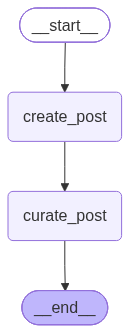

In [9]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(graphSchema)
graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)
graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)


from IPython.display import Image, display
pydantic_graph = graph.compile()




# You could see the errors with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())


In [10]:
pydantic_graph.invoke(
    {"topic": "The importance of data privacy in the digital age",
     "post": "",
     "curated_post": ""}
)

{'topic': 'The importance of data privacy in the digital age',
 'post': '\n<think>\nHere\'s a thinking thinking sequence\n\n1.  **Deconstruct the user\'s request:**\n    *   Topic: Importance of data privacy in the digital age.\n    *   Platform: LinkedIn.\n    *   Goal: Write a post.\n\n2.  **Determine the tone and style for LinkedIn:**\n    *   LinkedIn posts should be professional yet engaging.\n    *   They often use a hook to grab attention.\n    *   Structure matters: short paragraphs, bullet points, emojis (used sparingly but effectively), and a clear call to action (CTA).\n    *   The audience is professionals, so the content should touch on business implications, trust, compliance, and future trends, not just personal privacy.\n\n3.  **Brainstorm key themes/angles:**\n    *   *Why does data privacy matter?* Trust, brand reputation, legal compliance (GDPR, CCPA), customer loyalty, security vs. privacy distinction.\n    *   *What\'s the "Digital Age" context?* AI, big data, cons